## **Normalização e Padronização**

Uma atividade muito importante no pré-processamento de dados para modelos de machine learning, é a transformação dos dados com o objetivo de que todos fiquem com a **mesma ordem de grandeza**.

Isso **evita que o modelo fique enviesado**, dando maior peso para as variáveis de maior grandeza.

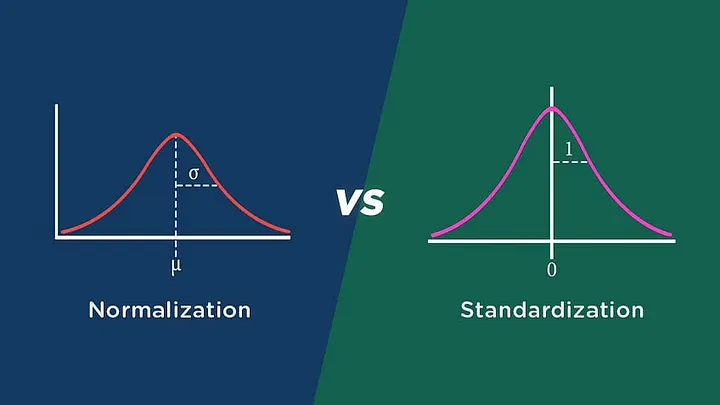

### **Normalização**

Tem como objetivo colocar os dados dentro do intervalo de 0 a 1 (ou -1 a 1, caso haja valores negativos), sem distorcer as diferenças nas faixas de valores reais.

É utilizada quando sabemos a distribuição dos dados, ou sabemos que não é uma distribuição normal, sendo útil principalmente em algoritmos que não fazem suposições sobre a distribuição.

#### **Normalização MinMax (fórmula)**:

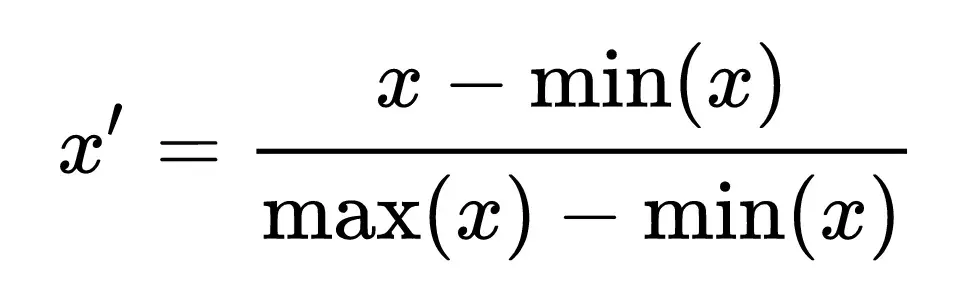

### **Padronização**

Tem como objetivo transformar os dados fazendo com que eles resultem em uma média igual a 0 e desvio padrão igual a 1.

É mais utilizada quando se sabe que a distribuição dos dados segue uma curva normal, ou muito próxima.

#### **Padronização Z-score (fórmula)**:

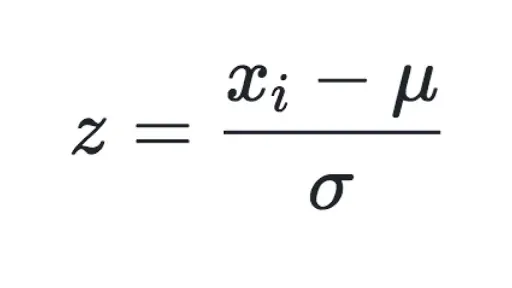

### **Observações**

- Não são técnicas obrigatórias, contudo, podem impactar nos resultados dos modelos de machine learning.

- A normalização não retira os outliers (valores extremos).

- A padronização também é afetada por outliers, pois utilizam a média e o desvio padrão.

### **Exemplo**:

In [1]:
import pandas as pd
from scipy import stats
from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [2]:
df_original = pd.read_csv("datasets/dados_credito.csv")

X_original, y_original = df_original.drop(columns=['Credito_liberado', 'Id']), df_original['Credito_liberado']

display(df_original)

,Id,Idade,Renda,Valor_investido,Tempo_Banco,Credito_liberado
0,1,55,10000,0,20,1
1,2,32,5000,10000,8,1
2,3,48,15000,7000,15,1
3,4,61,6000,12000,23,1
4,5,27,4000,500,12,0
5,6,19,800,0,0,0
6,7,31,4500,1200,4,0
7,8,72,6500,50000,28,1
8,9,56,9000,45000,17,1
9,10,81,4000,15000,33,1


In [3]:
# Analisar quais variáveis possuem uma distribuição aproximadamente normal:

def shapiro_teste(data):

    p_value = stats.shapiro(data)[1]

    return p_value

for col in X_original.columns:

    p_value = shapiro_teste(df_original[col])

    print(f"Column: {col:<{20}} | p_value: {p_value:.4f}")

Column: Idade                | p_value: 0.7279
Column: Renda                | p_value: 0.4119
Column: Valor_investido      | p_value: 0.0039
Column: Tempo_Banco          | p_value: 0.9923


- O p_value da variável "Valor_investido" é menor que 0.05, logo ela não possui uma distribuição normal.

In [4]:
# Aplicar a padronização e a normalização nas variáveis de acordo com os p_values do teste:

df_process = pd.DataFrame()

scaler_minmax = MinMaxScaler()
scaler_std = StandardScaler()

for col in X_original.columns:

    if col == 'Valor_investido':

        scaler_minmax.fit(df_original[[col]])
        df_process[col] = scaler_minmax.transform(df_original[[col]]).ravel()

    else:

        scaler_std.fit(df_original[[col]])
        df_process[col] = scaler_std.transform(df_original[[col]]).ravel()
    
df_process['Credito_liberado'] = y_original

display(df_process)

,Idade,Renda,Valor_investido,Tempo_Banco,Credito_liberado
0,0.350051,0.933336,0.000,0.404061,1
1,-0.833944,-0.392425,0.200,-0.808122,1
2,-0.010296,2.259097,0.140,-0.101015,1
3,0.658919,-0.127273,0.240,0.707107,1
4,-1.091335,-0.657577,0.010,-0.404061,0
5,-1.503159,-1.506064,0.000,-1.616244,0
6,-0.885422,-0.525001,0.024,-1.212183,0
7,1.225178,0.005303,1.000,1.212183,1
8,0.401529,0.668184,0.900,0.101015,1
9,1.688480,-0.657577,0.300,1.717259,1


In [5]:
X_process = df_process.drop(columns='Credito_liberado')
y_process = y_original

In [6]:
y_original.value_counts()

Credito_liberado
1    7
0    3
Name: count, dtype: int64

In [7]:
# Teste

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

knn = KNeighborsClassifier(n_neighbors=2)

score_data_original = cross_val_score(
    knn,
    X_original,
    y_original,
    cv=cv
)

score_data_process = cross_val_score(
    knn,
    X_process,
    y_process,
    cv=cv
)


print(f"Score dataset não processado: {score_data_original.mean()}")
print(f"Score dataset processado: {score_data_process.mean()}")

Score dataset não processado: 0.8333333333333334
Score dataset processado: 0.9166666666666666
